<a href="https://colab.research.google.com/github/Kovalivska/Python/blob/Study/Time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset
==
* Ads watched by players in real mobile game
* Data is aggregated hourly

Task
--
Predict ads views for the next 24 hours

In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv('/content/ads.csv')

In [4]:
# Let's check dataset
df.head()

,Time,Ads
0,2017-09-13T00:00:00,80115
1,2017-09-13T01:00:00,79885
2,2017-09-13T02:00:00,89325
3,2017-09-13T03:00:00,101930
4,2017-09-13T04:00:00,121630


Let's take a look at the components of the dataset
--

Firs we will create a `pandas` series with index from `Time` columns and data from `Ads` column

In [6]:

timeseries = pd.Series(index = pd.to_datetime(df['Time']),
                       data = df['Ads'].values)

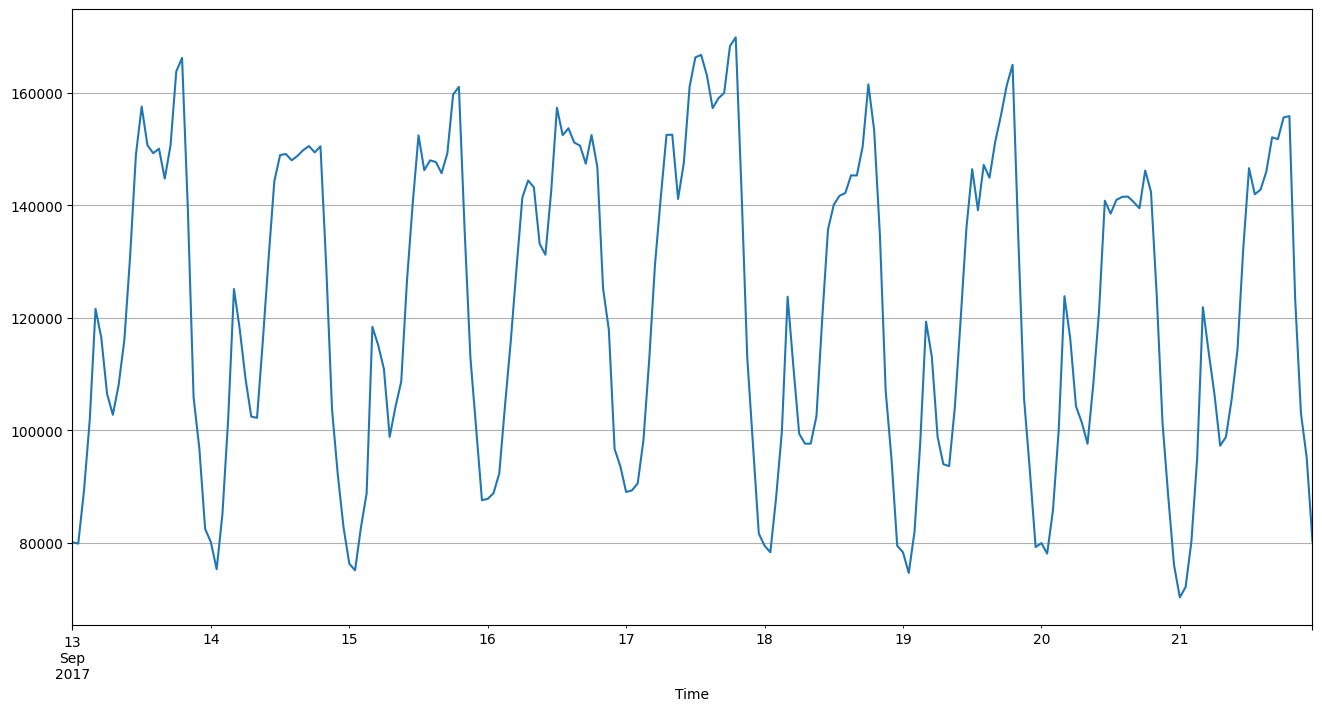

In [7]:
# plot Ads column
plt.figure(figsize = (16,8))
timeseries.plot()
plt.grid()
plt.show()

<Figure size 2000x800 with 0 Axes>

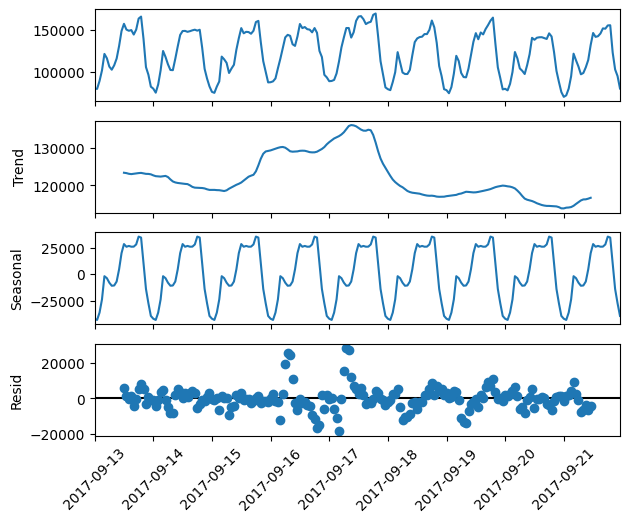

In [8]:
#import seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose

# decompose the
result = seasonal_decompose(timeseries)

#plot components
plt.figure(figsize = (20,8))
result.plot()
plt.xticks(rotation = 45)
plt.show()

Check if time series is stationary by running ADF test
--

In [9]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(timeseries)
p_value = adf_result[1]
if p_value <= 0.05:
        print("The series is stationary (reject H0).")
else:
    print("The series is non-stationary (fail to reject H0).")

The series is stationary (reject H0).


**Time series is stationary**

Check **ACF** and **PACF**
---

<Figure size 640x480 with 0 Axes>

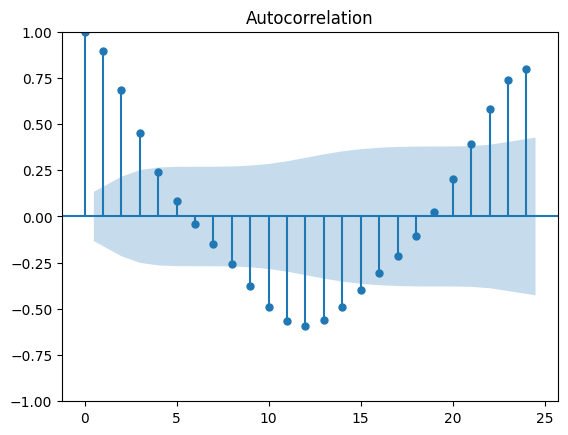

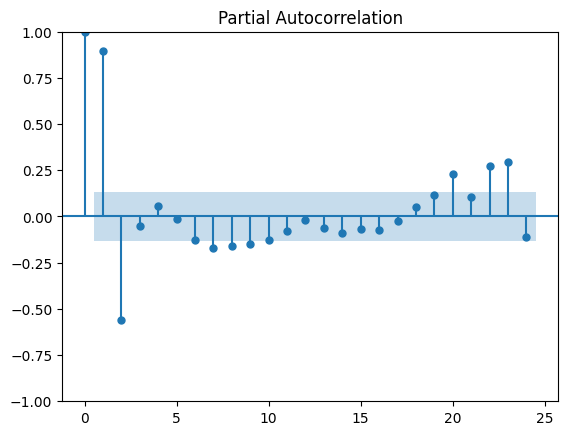

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


plt.figure()
plot_acf(timeseries)
plot_pacf(timeseries)
plt.show()

There is still seasonality present, which we need to remove for other models, but for now we can keep the timeseries as it is

Feature engineering
==

Lags of time series
--
* Choice of lags depends on autocorrelation and partial autocorrelation
* Also on what information will be available to us at prediction point
* Let's say we can use anything which is at least 24 hours before predictions

In [11]:
for i in [24,25,48]:
  df[f'lag_{i}'] = df['Ads'].shift(i)

Time based features
==

In [12]:
df['Time']= pd.to_datetime(df['Time'])
df['hour'] = df['Time'].dt.hour

Rolling window feature
--

In [13]:
# small example of rolling window
pd.Series([1,2,3,4,5]).rolling(window = 3).mean()

,0
0,NaN
1,NaN
2,2.0
3,3.0
4,4.0


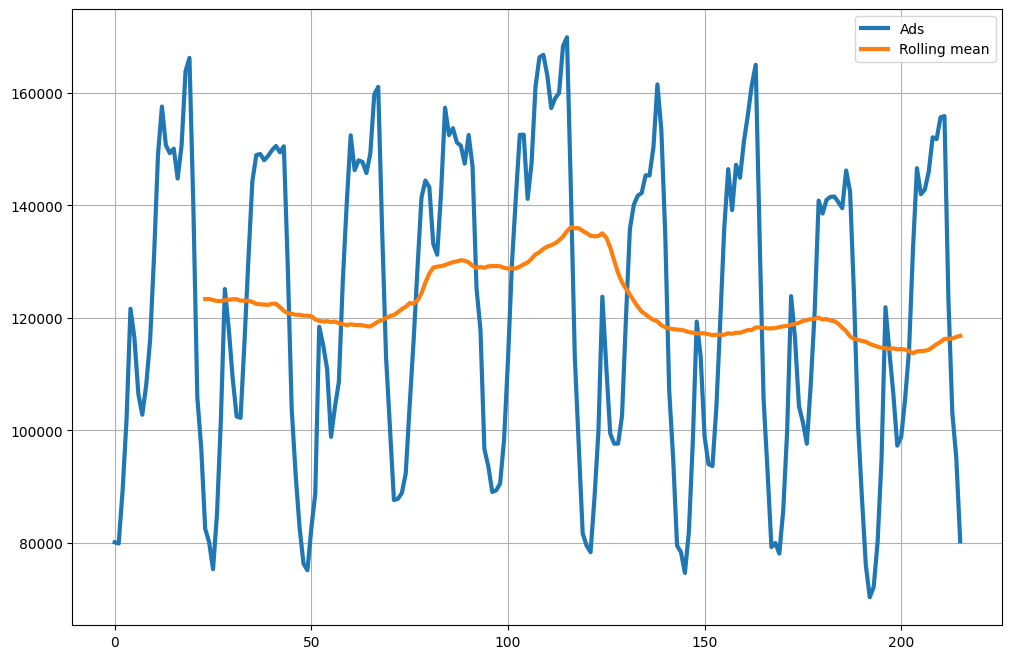

In [14]:
df['rolling_mean'] = df['Ads'].rolling(window = 24).mean()
plt.figure(figsize = (12,8))
plt.plot(df['Ads'], label ='Ads', lw=3)
plt.plot(df['rolling_mean'], label = 'Rolling mean', lw = 3)
plt.legend()
plt.grid()
plt.show()

We have to shift `rolling mean` on 24 as well

In [38]:
df['rolling_mean'] = df['rolling_mean'].shift(24)

Train test split
---
Since we have to predict for the next 24 hours, test size should be 24

In [39]:
df

,Time,Ads,lag_24,lag_25,lag_48,hour,rolling_mean
0,2017-09-13 00:00:00,80115,NaN,NaN,NaN,0,NaN
1,2017-09-13 01:00:00,79885,NaN,NaN,NaN,1,NaN
2,2017-09-13 02:00:00,89325,NaN,NaN,NaN,2,NaN
3,2017-09-13 03:00:00,101930,NaN,NaN,NaN,3,NaN
4,2017-09-13 04:00:00,121630,NaN,NaN,NaN,4,NaN
...,...,...,...,...,...,...,...
211,2017-09-21 19:00:00,155890,142425.0,146215.0,165010.0,19,129288.958333
212,2017-09-21 20:00:00,123395,123945.0,142425.0,134090.0,20,128860.833333
213,2017-09-21 21:00:00,103080,101360.0,123945.0,105585.0,21,129068.333333
214,2017-09-21 22:00:00,95155,88170.0,101360.0,92855.0,22,128922.500000


In [61]:
#remove null values
data = df.copy().dropna()
train, test  = data[:-24], data[-24:]


In [62]:
train.shape

(49, 7)

In [63]:
test.shape

(24, 7)

Linear regression
---
* Let's first build linear regression on created features
* We will use `R2 score` and `Root mean squared error`

In [64]:
#list of features
features = train.columns.drop(['Time','Ads'])
target = 'Ads'

#import linear model
from sklearn.linear_model import LinearRegression

#import metrics
from sklearn.metrics import r2_score, root_mean_squared_error

In [65]:
mod = LinearRegression()
mod.fit(train[features],train[target])
train_preds = mod.predict(train[features])
test_preds = mod.predict(test[features])

print(f'Train R2-score: {r2_score(train[target], train_preds):1.2f}')
print(f'Test R2-score: {r2_score(test[target], test_preds):1.2f}')

print(f'Train RMSE-score: {root_mean_squared_error(train[target], train_preds):1.2f}')
print(f'Test RMSE-score: {root_mean_squared_error(test[target], test_preds):1.2f}')

Train R2-score: 0.95
Test R2-score: 0.90
Train RMSE-score: 5797.20
Test RMSE-score: 8394.32


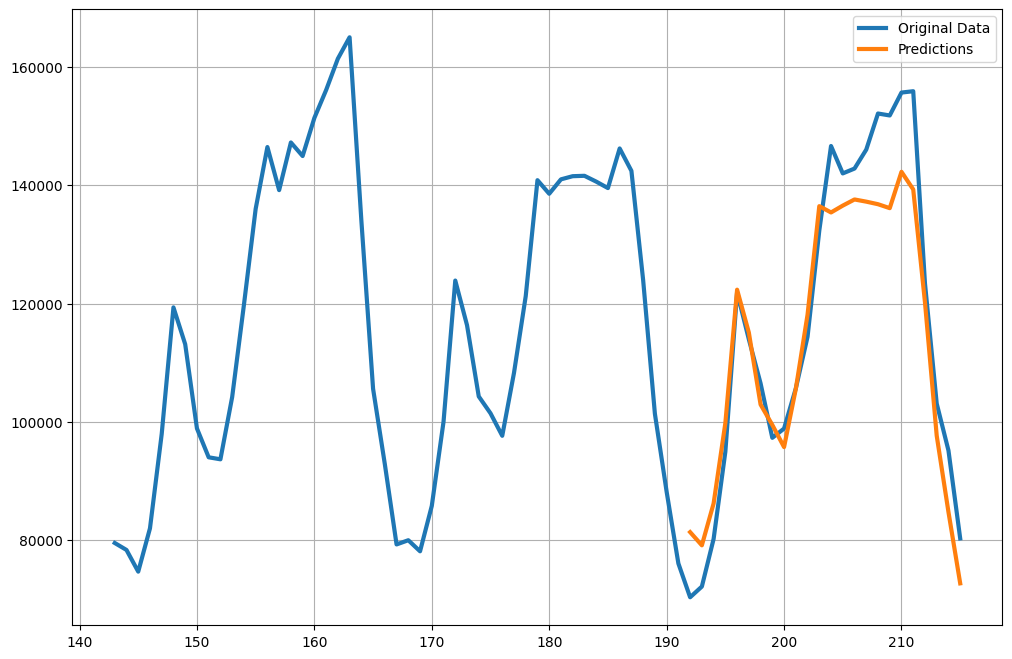

In [66]:
plt.figure(figsize = (12,8))
plt.plot(data['Ads'], lw=3, label ='Original Data')
plt.plot(pd.Series(index = test.index, data = test_preds),
         lw = 3,
         label = 'Predictions')
plt.grid()
plt.legend()
plt.show()

Time-series cross validation
==

In case some time left ask students to do forecasting for airline passengers